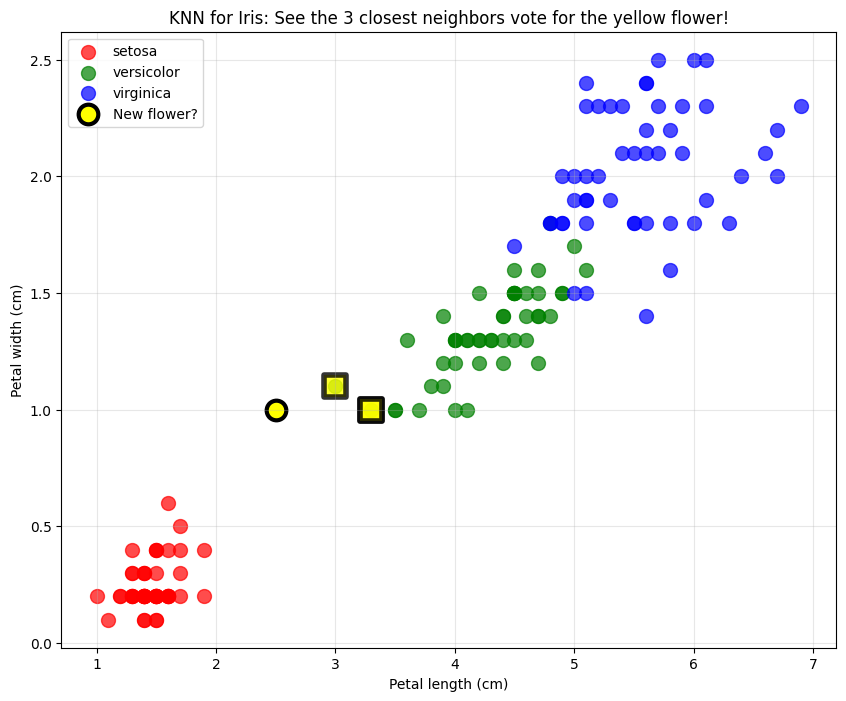

KNN predicts: versicolor (based on 3 nearest neighbors)


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier

#2 easy features (petal length, petal width)
iris = load_iris()
X = iris.data[:, [2, 3]]  # Petal length (col 2), petal width (col 3)
y = iris.target
species = iris.target_names  # ['setosa', 'versicolor', 'virginica']

# Plot ALL data points colored by species
plt.figure(figsize=(10, 8))
colors = ['red', 'green', 'blue']
for i in range(3):
    plt.scatter(X[y==i, 0], X[y==i, 1], c=colors[i], label=species[i], s=100, alpha=0.7)

# Add a NEW test flower (circled, yellow)
test_flower = np.array([[2.5, 1.0]])  # Looks like versicolor
plt.scatter(test_flower[:,0], test_flower[:,1], c='yellow', s=200, 
            marker='o', edgecolors='black', linewidth=3, label='New flower?')

# Train super-simple KNN (k=3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)

# Find & highlight the 3 NEAREST neighbors to test flower
dist, neigh_idx = knn.kneighbors(test_flower)
for idx in neigh_idx[0]:
    plt.scatter(X[idx, 0], X[idx, 1], c='yellow', s=250, 
                marker='s', edgecolors='black', linewidth=4, alpha=0.8)

plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('KNN for Iris: 3 closest neighbors vote for the yellow flower!')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print prediction
pred = knn.predict(test_flower)[0]
print(f"KNN predicts: {species[pred]} (based on 3 nearest neighbors)")
